# Model Evaluation — Recommended Configuration
**P2B · Patient Max Pooling · 4-Way TTA · Argmax Decision**

Comprehensive evaluation on the held-out test set (175 patients).

Sections: Setup · Overall Metrics · Per-Class Metrics · Confusion Matrix · ROC Curves · Precision-Recall · Sensitivity & Specificity · Probability Distributions · Classification Report · Summary Dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

TEAL         = '#006B6B'
CLASS_NAMES  = ['R0', 'R1', 'R2', 'R3A']
CLASS_LABELS = ['R0 (Normal)', 'R1 (Mild/Mod NPDR)', 'R2 (Mod/Sev NPDR)', 'R3A (PDR)']
CLASS_COLORS = ['#1A9E77', '#D95F02', '#7570B3', '#E7298A']
OUTPUT_DIR   = Path('output_dir')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Apply Recommended Pipeline

In [2]:
test_tta_prbs = np.load(OUTPUT_DIR / 'phase2b_cv/test_tta_probs.npy')

GRADE   = {'R0': 0, 'R1': 1, 'R2': 2, 'R3A': 3}
df_all  = pd.read_csv('labels/splits.csv')
df_test = df_all[df_all['split'] == 'test'].copy().reset_index(drop=True)
df_test['grade_int'] = df_test['retinopathy'].map(GRADE)

test_codes  = df_test['code'].values
test_labels = df_test['grade_int'].values

# normalise
test_tta_prbs = test_tta_prbs / test_tta_prbs.sum(axis=1, keepdims=True)

# patient MEAN pooling (recommended config: PtMean + TTA)
records = {}
for c, prob, label in zip(test_codes, test_tta_prbs, test_labels):
    if c not in records:
        records[c] = {'probs': [], 'worst_grade': 0}
    records[c]['probs'].append(prob)
    records[c]['worst_grade'] = max(records[c]['worst_grade'], int(label))

patient_codes = sorted(records.keys())
pt_probs, pt_labels = [], []
for c in patient_codes:
    p = np.stack(records[c]['probs']).mean(axis=0)
    p = p / p.sum()
    pt_probs.append(p)
    pt_labels.append(records[c]['worst_grade'])

pt_probs  = np.array(pt_probs)
pt_labels = np.array(pt_labels)
pt_preds  = pt_probs.argmax(axis=1)

print(f'Patients : {len(pt_labels)}')
vals, cnts = np.unique(pt_labels, return_counts=True)
print('Class distribution:', {CLASS_NAMES[v]: c for v, c in zip(vals, cnts)})

Patients : 323
Class distribution: {'R0': 173, 'R1': 116, 'R2': 20, 'R3A': 14}


## 2. Overall Metrics

In [3]:
accuracy   = accuracy_score(pt_labels, pt_preds)
kappa      = cohen_kappa_score(pt_labels, pt_preds, weights='quadratic')
auroc      = roc_auc_score(pt_labels, pt_probs, multi_class='ovr', average='macro')
macro_prec = precision_score(pt_labels, pt_preds, average='macro',    zero_division=0)
macro_rec  = recall_score(pt_labels,   pt_preds, average='macro',    zero_division=0)
macro_f1   = f1_score(pt_labels,       pt_preds, average='macro',    zero_division=0)
wt_prec    = precision_score(pt_labels, pt_preds, average='weighted', zero_division=0)
wt_rec     = recall_score(pt_labels,   pt_preds, average='weighted', zero_division=0)
wt_f1      = f1_score(pt_labels,       pt_preds, average='weighted', zero_division=0)

print('=' * 52)
print(f'  OVERALL METRICS  —  Test Set ({len(pt_labels)} patients)')
print('=' * 52)
print(f'  Accuracy              : {accuracy:.4f}  ({int(accuracy*len(pt_labels))}/{len(pt_labels)})')
print(f"  Cohen's Kappa (quad.) : {kappa:.4f}")
print(f'  Macro AUROC           : {auroc:.4f}')
print()
print(f'  Macro  Precision      : {macro_prec:.4f}')
print(f'  Macro  Recall         : {macro_rec:.4f}')
print(f'  Macro  F1             : {macro_f1:.4f}')
print()
print(f'  Weighted Precision    : {wt_prec:.4f}')
print(f'  Weighted Recall       : {wt_rec:.4f}')
print(f'  Weighted F1           : {wt_f1:.4f}')
print('=' * 52)

  OVERALL METRICS  —  Test Set (323 patients)
  Accuracy              : 0.8483  (274/323)
  Cohen's Kappa (quad.) : 0.8501
  Macro AUROC           : 0.9475

  Macro  Precision      : 0.8126
  Macro  Recall         : 0.7513
  Macro  F1             : 0.7733

  Weighted Precision    : 0.8516
  Weighted Recall       : 0.8483
  Weighted F1           : 0.8427


## 3. Per-Class Metrics

In [4]:
cm = confusion_matrix(pt_labels, pt_preds, labels=[0,1,2,3])
pt_labels_bin = label_binarize(pt_labels, classes=[0,1,2,3])

per_class = []
for i in range(4):
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0.0
    npv  = tn/(tn+fn) if (tn+fn)>0 else 0.0
    f1   = 2*ppv*sens/(ppv+sens) if (ppv+sens)>0 else 0.0
    yj   = sens + spec - 1
    auc_i = roc_auc_score(pt_labels_bin[:,i], pt_probs[:,i])
    per_class.append({
        'Class': CLASS_LABELS[i], 'N': int(cm[i].sum()),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'Sensitivity': sens, 'Specificity': spec,
        'Precision':   ppv,  'NPV':        npv,
        'F1': f1, 'AUROC': auc_i, 'Youden J': yj,
    })

df_pc = pd.DataFrame(per_class).set_index('Class')
show  = ['N','TP','FP','FN','TN','Sensitivity','Specificity','Precision','NPV','F1','AUROC','Youden J']
print(df_pc[show].to_string(float_format='{:.4f}'.format))

                      N   TP  FP  FN   TN  Sensitivity  Specificity  Precision    NPV     F1  AUROC  Youden J
Class                                                                                                        
R0 (Normal)         173  169  31   4  119       0.9769       0.7933     0.8450 0.9675 0.9062 0.9308    0.7702
R1 (Mild/Mod NPDR)  116   82  10  34  197       0.7069       0.9517     0.8913 0.8528 0.7885 0.9001    0.6586
R2 (Mod/Sev NPDR)    20   15   6   5  297       0.7500       0.9802     0.7143 0.9834 0.7317 0.9795    0.7302
R3A (PDR)            14    8   2   6  307       0.5714       0.9935     0.8000 0.9808 0.6667 0.9794    0.5650


## 4. Confusion Matrix

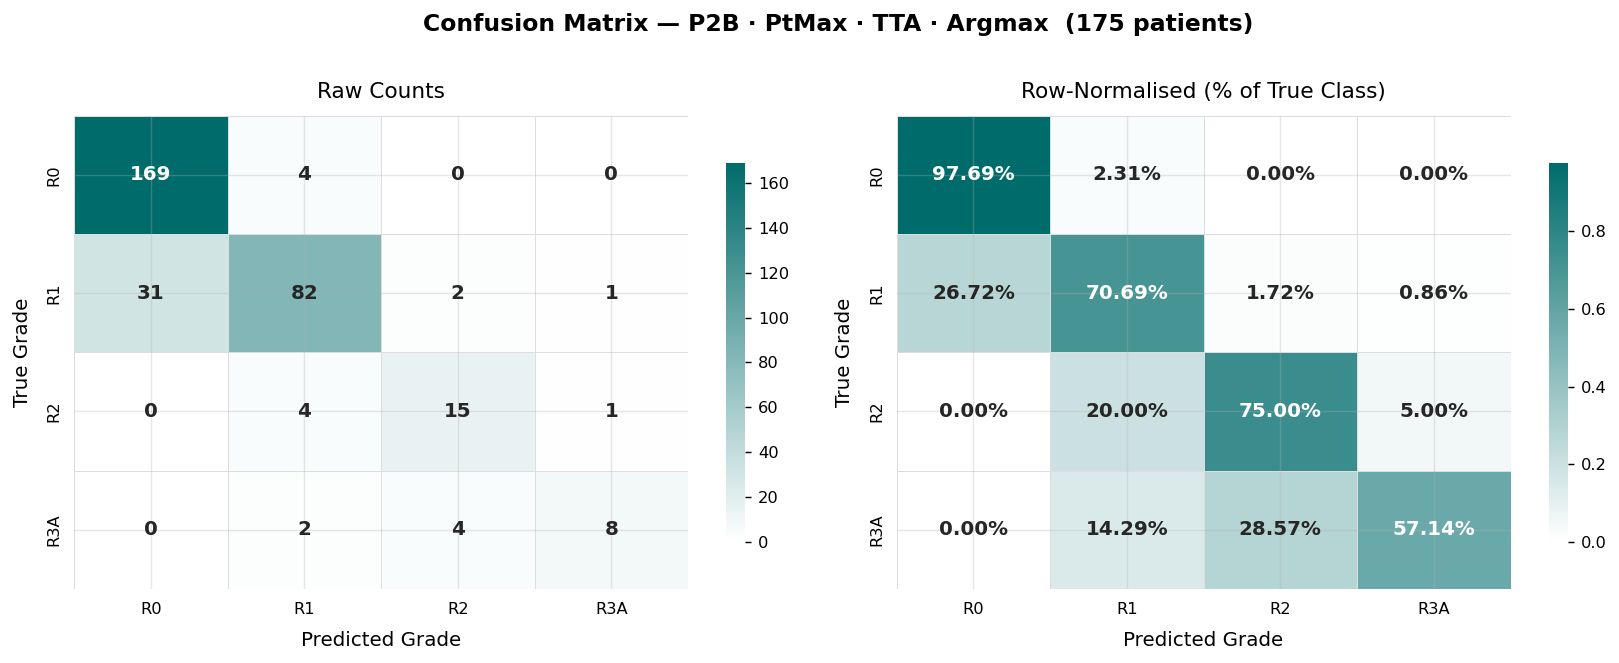

Saved figures/confusion_matrix.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — P2B · PtMax · TTA · Argmax  (175 patients)',
             fontsize=13, fontweight='bold', y=1.01)

teal_cmap = LinearSegmentedColormap.from_list('tc', ['#FFFFFF', TEAL])
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Row-Normalised (% of True Class)']
):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=teal_cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='#DDDDDD', cbar_kws={'shrink':0.8},
                annot_kws={'size':11,'weight':'bold'})
    ax.set_xlabel('Predicted Grade', labelpad=8)
    ax.set_ylabel('True Grade', labelpad=8)
    ax.set_title(title, pad=10)
    ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/confusion_matrix.png')

## 5. ROC Curves

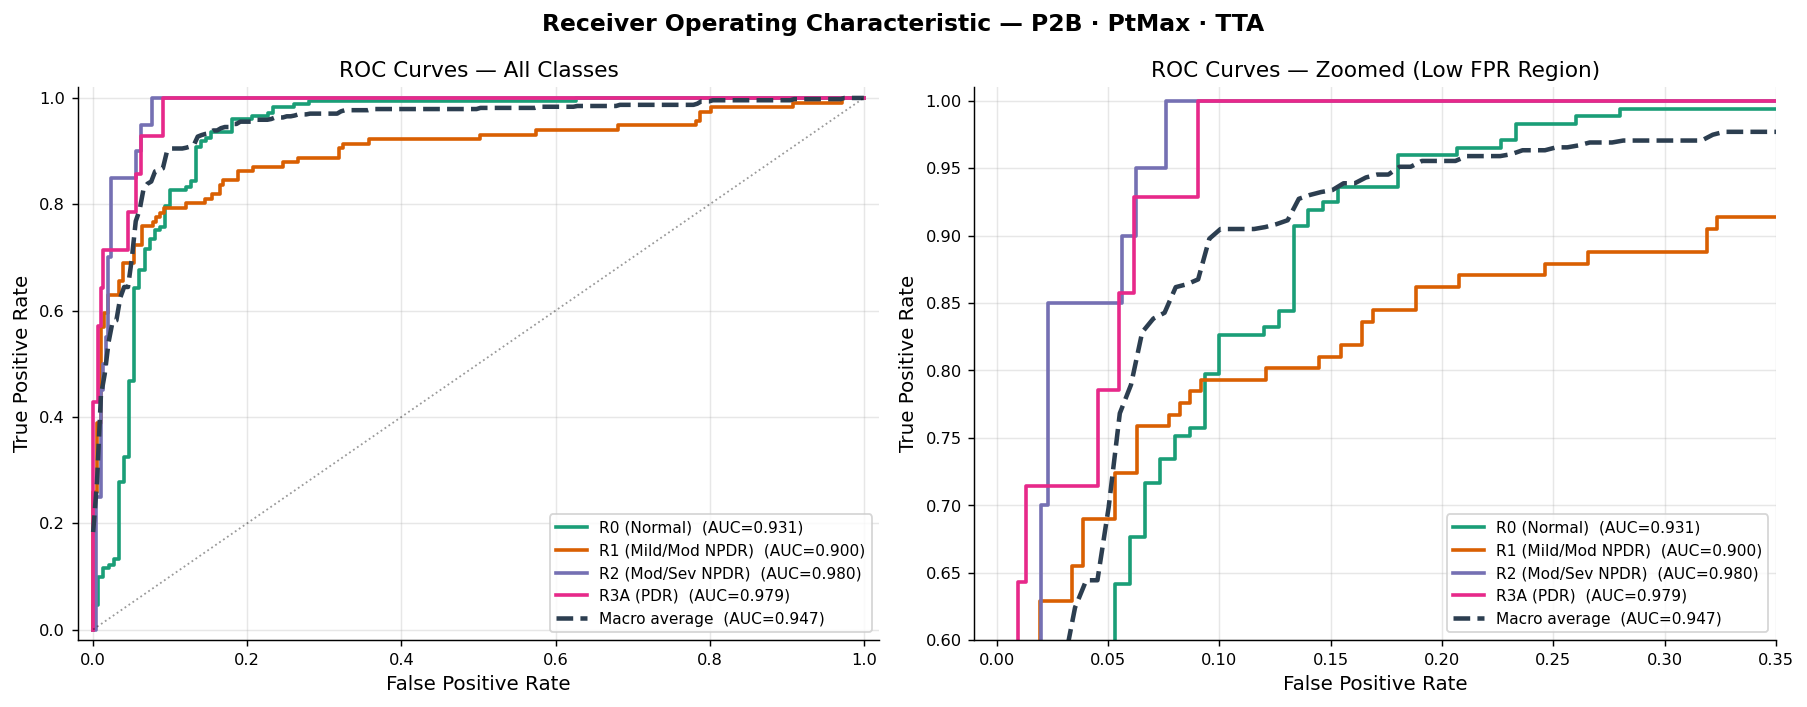

Saved figures/roc_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

macro_tprs, mean_fpr = [], np.linspace(0, 1, 200)
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(pt_labels_bin[:,i], pt_probs[:,i])
    auc_i = roc_auc_score(pt_labels_bin[:,i], pt_probs[:,i])
    for ax in axes:
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{CLASS_LABELS[i]}  (AUC={auc_i:.3f})')
    macro_tprs.append(np.interp(mean_fpr, fpr, tpr))

macro_tpr = np.mean(macro_tprs, axis=0)
for ax in axes:
    ax.plot(mean_fpr, macro_tpr, color='#2C3E50', lw=2.5, ls='--',
            label=f'Macro average  (AUC={auroc:.3f})')
    ax.plot([0,1],[0,1],'k:',lw=1,alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8.5, loc='lower right')

axes[0].set_title('ROC Curves — All Classes')
axes[0].set_xlim(-0.02,1.02); axes[0].set_ylim(-0.02,1.02)
axes[1].set_title('ROC Curves — Zoomed (Low FPR Region)')
axes[1].set_xlim(-0.01, 0.35); axes[1].set_ylim(0.60, 1.01)

fig.suptitle('Receiver Operating Characteristic — P2B · PtMax · TTA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/roc_curves.png')

## 6. Precision-Recall Curves

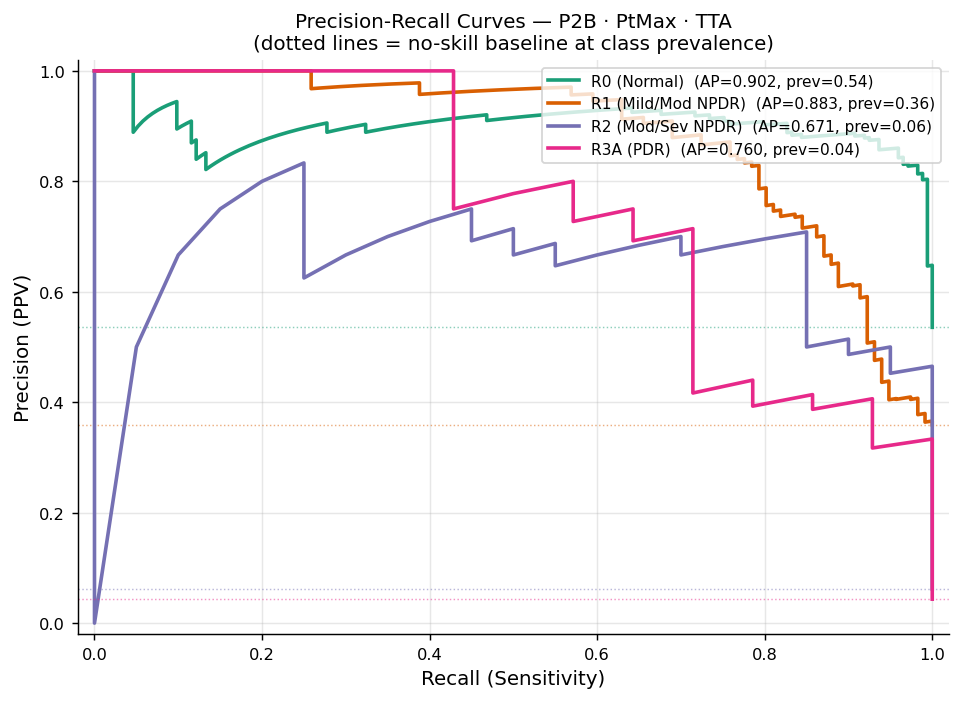

Saved figures/precision_recall_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for i, (name, label, color) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    prec, rec, _ = precision_recall_curve(pt_labels_bin[:,i], pt_probs[:,i])
    ap   = average_precision_score(pt_labels_bin[:,i], pt_probs[:,i])
    prev = pt_labels_bin[:,i].mean()
    ax.plot(rec, prec, color=color, lw=2, label=f'{label}  (AP={ap:.3f}, prev={prev:.2f})')
    ax.axhline(prev, color=color, lw=0.8, ls=':', alpha=0.5)

ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
title_line1 = 'Precision-Recall Curves — P2B · PtMax · TTA'
title_line2 = '(dotted lines = no-skill baseline at class prevalence)'
ax.set_title(title_line1 + '\n' + title_line2, fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)

plt.tight_layout()
plt.savefig('figures/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/precision_recall_curves.png')

## 7. Sensitivity & Specificity

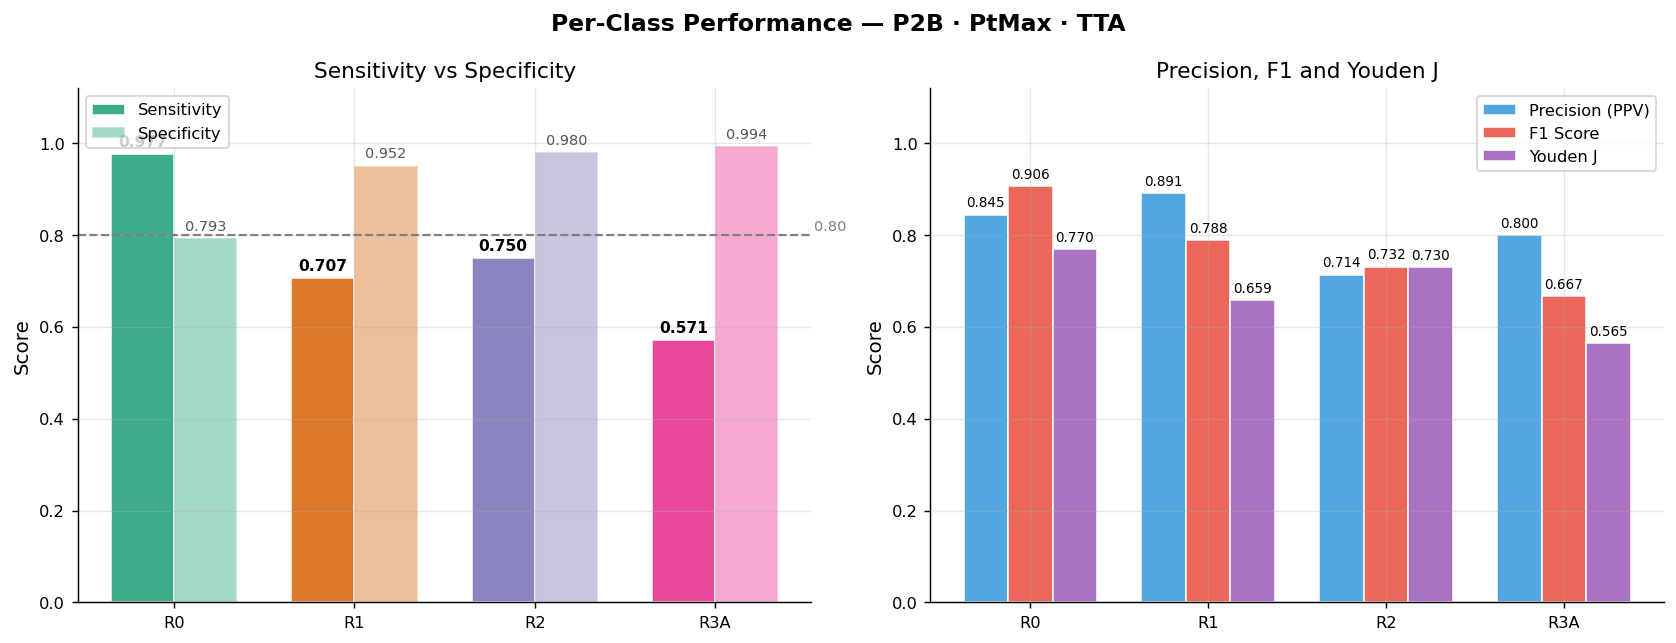

Saved figures/sensitivity_specificity.png


In [8]:
sens_vals = [r['Sensitivity']  for r in per_class]
spec_vals = [r['Specificity']  for r in per_class]
prec_vals = [r['Precision']    for r in per_class]
f1_vals   = [r['F1']           for r in per_class]
yj_vals   = [r['Youden J']     for r in per_class]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x, w = np.arange(4), 0.35

# left: sensitivity vs specificity
ax = axes[0]
b1 = ax.bar(x-w/2, sens_vals, w, label='Sensitivity',  color=CLASS_COLORS, alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, spec_vals, w, label='Specificity',  color=CLASS_COLORS, alpha=0.40, edgecolor='white')
ax.axhline(0.80, color='grey', ls='--', lw=1.2)
ax.text(3.55, 0.81, '0.80', fontsize=8, color='grey')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#555')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0,1.12); ax.set_ylabel('Score')
ax.set_title('Sensitivity vs Specificity'); ax.legend(fontsize=9)

# right: precision, F1, Youden J
ax2, w3 = axes[1], 0.25
ax2.bar(x-w3, prec_vals, w3, label='Precision (PPV)', color='#3498DB', alpha=0.85, edgecolor='white')
ax2.bar(x,    f1_vals,   w3, label='F1 Score',        color='#E74C3C', alpha=0.85, edgecolor='white')
ax2.bar(x+w3, yj_vals,   w3, label='Youden J',        color='#9B59B6', alpha=0.85, edgecolor='white')
for j,(p,f,y) in enumerate(zip(prec_vals,f1_vals,yj_vals)):
    for xpos,val in [(j-w3,p),(j,f),(j+w3,y)]:
        ax2.text(xpos, max(val,0)+0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=7.5)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylim(0,1.12); ax2.set_ylabel('Score')
ax2.set_title('Precision, F1 and Youden J'); ax2.legend(fontsize=9)

fig.suptitle('Per-Class Performance — P2B · PtMax · TTA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/sensitivity_specificity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/sensitivity_specificity.png')

## 8. Probability Distributions

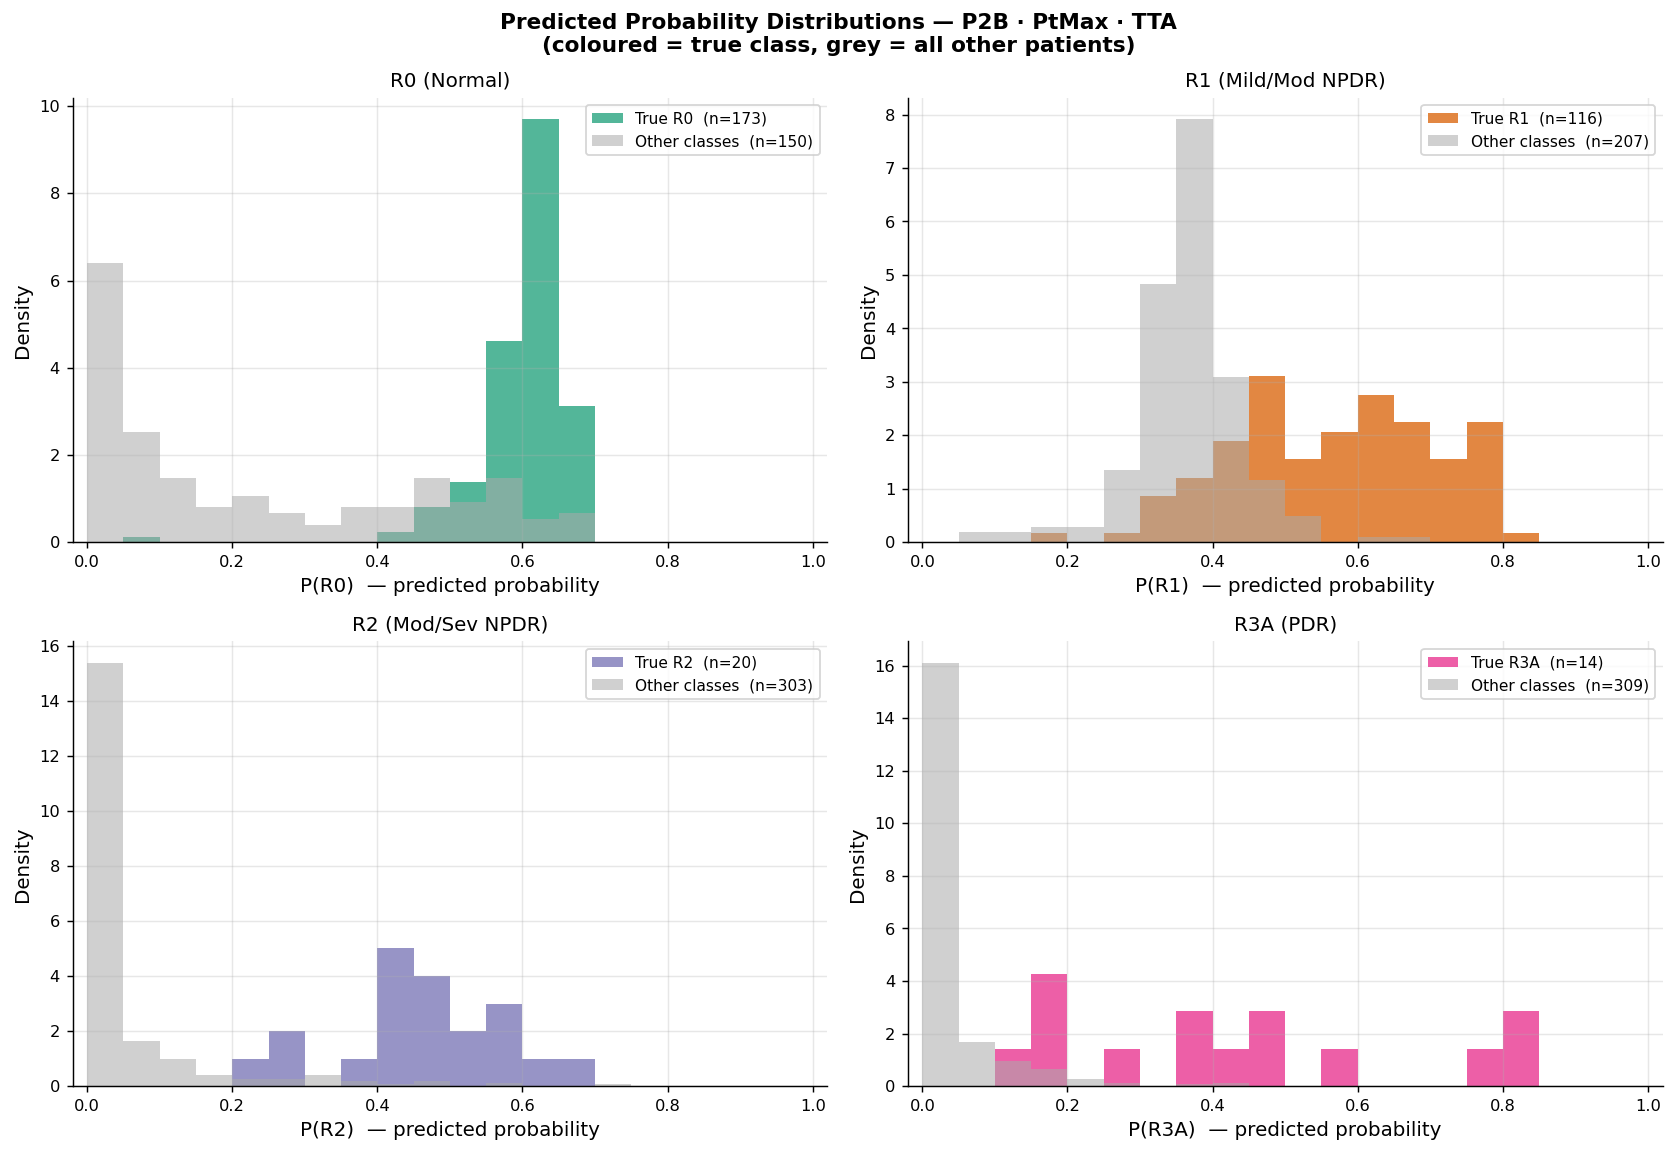

Saved figures/probability_distributions.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i,(cn,cl,color) in enumerate(zip(CLASS_NAMES,CLASS_LABELS,CLASS_COLORS)):
    ax = axes[i]
    is_true = (pt_labels == i)
    ax.hist(pt_probs[is_true, i],  bins=20, range=(0,1), color=color,
            alpha=0.75, label=f'True {cn}  (n={is_true.sum()})', density=True)
    ax.hist(pt_probs[~is_true, i], bins=20, range=(0,1), color='#AAAAAA',
            alpha=0.55, label=f'Other classes  (n={(~is_true).sum()})', density=True)
    ax.set_xlabel(f'P({cn})  — predicted probability')
    ax.set_ylabel('Density')
    ax.set_title(cl, fontsize=11)
    ax.set_xlim(-0.02, 1.02)
    ax.legend(fontsize=8.5)

title_str = ('Predicted Probability Distributions — P2B · PtMax · TTA\n'
             '(coloured = true class, grey = all other patients)')
fig.suptitle(title_str, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/probability_distributions.png')

## 9. Full Classification Report

In [10]:
print('Classification Report')
print('=' * 65)
print(classification_report(
    pt_labels, pt_preds,
    target_names=CLASS_LABELS,
    digits=4, zero_division=0
))
print('=' * 65)
print(f'  Accuracy              : {accuracy:.4f}')
print(f"  Cohen's Kappa (quad.) : {kappa:.4f}")
print(f'  Macro AUROC           : {auroc:.4f}')
print()
print('Per-Class AUROC:')
for i,name in enumerate(CLASS_LABELS):
    auc_i = roc_auc_score(pt_labels_bin[:,i], pt_probs[:,i])
    print(f'  {name:<28}: {auc_i:.4f}')
print('=' * 65)

Classification Report
                    precision    recall  f1-score   support

       R0 (Normal)     0.8450    0.9769    0.9062       173
R1 (Mild/Mod NPDR)     0.8913    0.7069    0.7885       116
 R2 (Mod/Sev NPDR)     0.7143    0.7500    0.7317        20
         R3A (PDR)     0.8000    0.5714    0.6667        14

          accuracy                         0.8483       323
         macro avg     0.8126    0.7513    0.7733       323
      weighted avg     0.8516    0.8483    0.8427       323

  Accuracy              : 0.8483
  Cohen's Kappa (quad.) : 0.8501
  Macro AUROC           : 0.9475

Per-Class AUROC:
  R0 (Normal)                 : 0.9308
  R1 (Mild/Mod NPDR)          : 0.9001
  R2 (Mod/Sev NPDR)           : 0.9795
  R3A (PDR)                   : 0.9794


## 10. Summary Dashboard

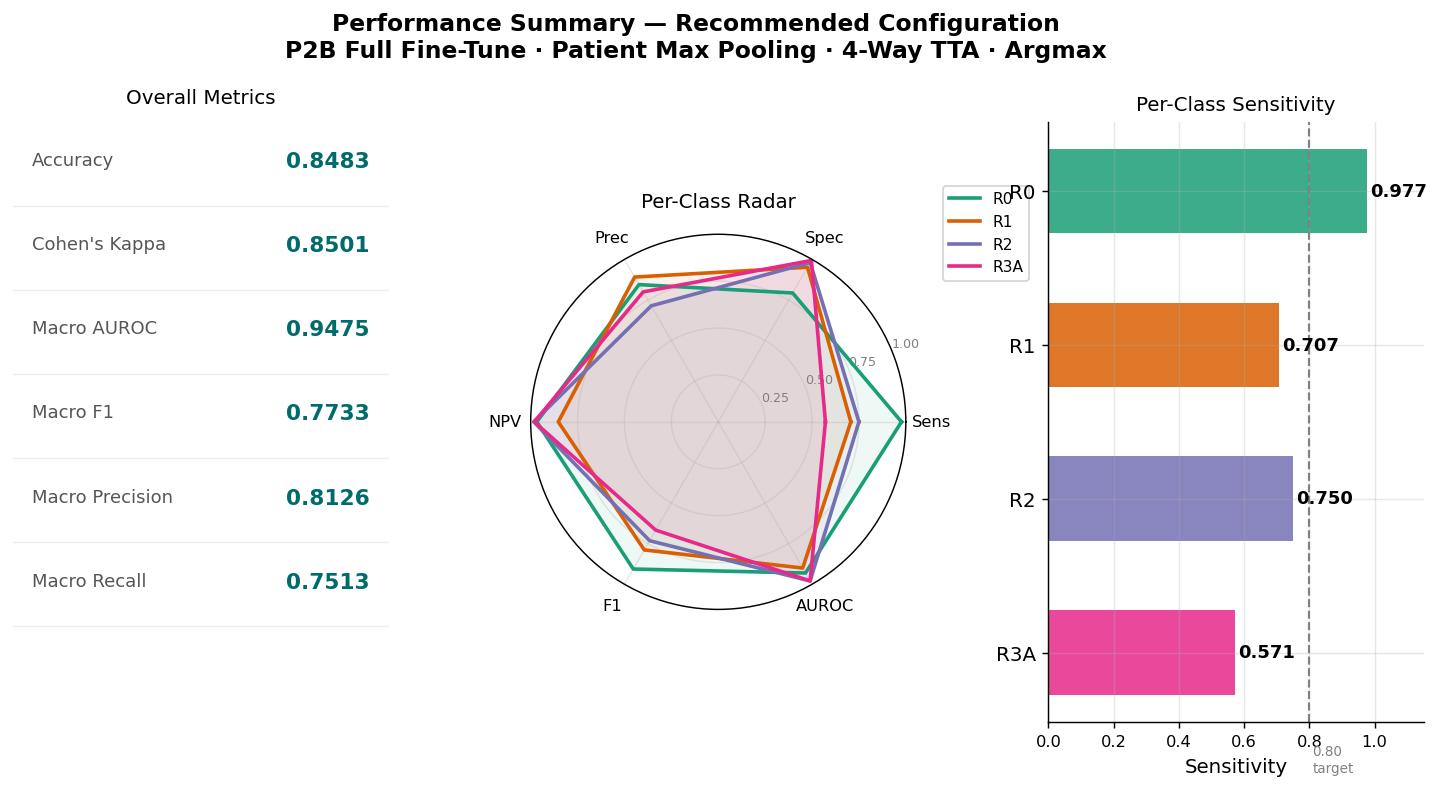

Saved figures/performance_dashboard.png


In [11]:
fig = plt.figure(figsize=(14, 6))
title_str = ('Performance Summary — Recommended Configuration\n'
             'P2B Full Fine-Tune · Patient Max Pooling · 4-Way TTA · Argmax')
fig.suptitle(title_str, fontsize=13, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Panel 1: KPI table
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')
kpis = [
    ('Accuracy',         f'{accuracy:.4f}'),
    ("Cohen's Kappa",    f'{kappa:.4f}'),
    ('Macro AUROC',      f'{auroc:.4f}'),
    ('Macro F1',         f'{macro_f1:.4f}'),
    ('Macro Precision',  f'{macro_prec:.4f}'),
    ('Macro Recall',     f'{macro_rec:.4f}'),
]
y0 = 0.95
for label, val in kpis:
    ax1.text(0.05, y0, label, transform=ax1.transAxes,
             fontsize=10, color='#555', va='top')
    ax1.text(0.95, y0, val, transform=ax1.transAxes,
             fontsize=12, fontweight='bold', color=TEAL, va='top', ha='right')
    y0 -= 0.14
    ax1.plot([0, 1], [y0+0.05, y0+0.05], color='#EEE', lw=0.8,
             transform=ax1.transAxes, clip_on=False)
ax1.set_title('Overall Metrics', fontsize=11, pad=10)

# Panel 2: radar
ax2 = fig.add_subplot(gs[1], polar=True)
radar_labels = ['Sens', 'Spec', 'Prec', 'NPV', 'F1', 'AUROC']
N      = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
for i,(cn,color) in enumerate(zip(CLASS_NAMES,CLASS_COLORS)):
    vals = [
        per_class[i]['Sensitivity'], per_class[i]['Specificity'],
        per_class[i]['Precision'],   per_class[i]['NPV'],
        per_class[i]['F1'],          per_class[i]['AUROC'],
    ]
    vals += vals[:1]
    ax2.plot(angles, vals, color=color, lw=2, label=cn)
    ax2.fill(angles, vals, color=color, alpha=0.07)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_labels, fontsize=9)
ax2.set_ylim(0,1)
ax2.set_yticks([0.25,0.5,0.75,1.0])
ax2.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7, color='grey')
ax2.set_title('Per-Class Radar', fontsize=11, pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=8.5)

# Panel 3: sensitivity bars
ax3 = fig.add_subplot(gs[2])
bars = ax3.barh(np.arange(4), sens_vals, color=CLASS_COLORS, alpha=0.85, height=0.55)
ax3.axvline(0.80, color='grey', ls='--', lw=1.2)
ax3.text(0.81, 3.6, '0.80\ntarget', fontsize=7.5, color='grey', va='top')
for bar, val in zip(bars, sens_vals):
    ax3.text(val+0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax3.set_yticks(np.arange(4))
ax3.set_yticklabels(CLASS_NAMES, fontsize=11)
ax3.set_xlim(0, 1.15)
ax3.set_xlabel('Sensitivity')
ax3.set_title('Per-Class Sensitivity', fontsize=11)
ax3.invert_yaxis()

plt.savefig('figures/performance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/performance_dashboard.png')